# USGS National Water-Quality Assessment (NAWQA) Project: Pesticide National Synthesis Project


* Provides annual agricultural pesticide use estimates by county, based on farm surveys of pesticide use and estimates of harvested crop acres. [LINK](https://water.usgs.gov/nawqa/pnsp/usage/maps/county-level/)

* The website also provides maps of agricultural pesticide use on a finer scale which are created by allocating the county-level estimates to agricultural land within each county. A graph accompanies each map and shows annual national use by major crop for the mapped pesticide for each year. More on how these are generated: [LINK](https://water.usgs.gov/nawqa/pnsp/usage/maps/about.php)

* Available time range: 1992–2019

* Consists of a tab-separated file (txt) for each year from 1992 to 2012, and an additional metadata file (xml) for 2013-2017 range, 2018, and 2019. The metadata contains details on how the dataset was produced and the FIPS code used.

* The estimate will be NaN if there were not enough data to make an estimate -- which I assume will be more prevalent for older years.

* Though I'm ignoring this for the sake of time, since FIPS code had slight changes over time, albeit limited to small number of states, the best practice would be to grab FIPS code chart from the census for each publication year. (e.g. [2017 FIPS](https://www.census.gov/geographies/reference-files/2017/demo/popest/2017-fips.html))


In [1]:
# load relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load estimates from 2013 to 2017
df = pd.read_csv('https://www.sciencebase.gov/catalog/file/get/5e95c12282ce172707f2524e?f=__disk__62%2F83%2Fd3%2F6283d3501f1028b1ccc3976ea2e6de848bc2fef8&allowOpen=true',sep='\t')
df.head()

,COMPOUND,YEAR,STATE_FIPS_CODE,COUNTY_FIPS_CODE,EPEST_LOW_KG,EPEST_HIGH_KG
0,1-METHYL CYCLOPROPENE,2013,41,1,NaN,0.0
1,1-METHYL CYCLOPROPENE,2013,41,21,NaN,0.0
2,1-METHYL CYCLOPROPENE,2013,41,27,NaN,0.2
3,1-METHYL CYCLOPROPENE,2013,41,49,NaN,0.0
4,1-METHYL CYCLOPROPENE,2013,41,55,NaN,0.0


In [4]:
# 2018 and 2019 have separate txt files
df2018 = pd.read_csv('https://www.sciencebase.gov/catalog/file/get/6081a706d34e8564d686618e?f=__disk__58%2F6a%2Fed%2F586aed9a844eac0174a0600c8a7293ec4cda0265&allowOpen=true',sep='\t')
df2018.head()

,COMPOUND,YEAR,STATE_FIPS_CODE,COUNTY_FIPS_CODE,EPEST_LOW_KG,EPEST_HIGH_KG
0,1-METHYL CYCLOPROPENE,2018,36,3,0.1,0.1
1,1-METHYL CYCLOPROPENE,2018,36,7,NaN,0.1
2,1-METHYL CYCLOPROPENE,2018,36,9,0.1,0.1
3,1-METHYL CYCLOPROPENE,2018,36,11,NaN,0.1
4,1-METHYL CYCLOPROPENE,2018,36,13,0.1,0.1


In [5]:
df2019 = pd.read_csv('https://www.sciencebase.gov/catalog/file/get/6081a924d34e8564d68661a1?f=__disk__08%2F42%2Fcd%2F0842cdac3a7d8b5056645a4dc08d1da96ad4e0b7&allowOpen=true',sep='\t')
df2019.head()

,COMPOUND,YEAR,STATE_FIPS_CODE,COUNTY_FIPS_CODE,EPEST_LOW_KG,EPEST_HIGH_KG
0,"2,4-D",2019,1,1,3955.7,3951.6
1,"2,4-D",2019,1,3,2519.1,2901.5
2,"2,4-D",2019,1,5,5411.8,5639.1
3,"2,4-D",2019,1,7,1404.8,1527.6
4,"2,4-D",2019,1,9,17250.2,17384.7


In [6]:
# for years 1992-2012, you can grab the text files from the url directly from their website
# could potentially loop over across all years and append to the same dataframe, 
# granted that they use the same format of urls and just change the year
for year in range(1992,2013):
    url = 'https://water.usgs.gov/nawqa/pnsp/usage/maps/county-level/PesticideUseEstimates/EPest.county.estimates.'+str(year)+'.txt'
    this_df = pd.read_csv(url,sep='\t')
    df = pd.concat([df,this_df])

In [7]:
df = pd.concat([df,df2018,df2019])

In [8]:
years = df['YEAR'].unique()
years.sort()
print(years)

[1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019]


In [9]:
df.describe()

,YEAR,STATE_FIPS_CODE,COUNTY_FIPS_CODE,EPEST_LOW_KG,EPEST_HIGH_KG
count,9.562214e+06,9.562214e+06,9.562214e+06,6.120573e+06,9.560938e+06
mean,2.005740e+03,3.067290e+01,9.611447e+01,1.815101e+03,1.374774e+03
std,7.829087e+00,1.479499e+01,8.677781e+01,2.713941e+04,2.243092e+04
min,1.992000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.999000e+03,1.900000e+01,3.500000e+01,2.000000e+00,2.700000e+00
50%,2.006000e+03,2.900000e+01,7.700000e+01,2.020000e+01,2.370000e+01
75%,2.013000e+03,4.500000e+01,1.310000e+02,2.005000e+02,1.907000e+02
max,2.019000e+03,5.600000e+01,8.100000e+02,9.623804e+06,9.623804e+06


In [10]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 9562214 entries, 0 to 107741
Data columns (total 6 columns):
 #   Column            Dtype  
---  ------            -----  
 0   COMPOUND          str    
 1   YEAR              int64  
 2   STATE_FIPS_CODE   int64  
 3   COUNTY_FIPS_CODE  int64  
 4   EPEST_LOW_KG      float64
 5   EPEST_HIGH_KG     float64
dtypes: float64(2), int64(3), str(1)
memory usage: 609.5 MB


In [11]:
# There's counties with the same code in different states, so we'll need to create another column that is state+county code so that we get unique county codes.
df['STATE_FIPS_CODE'] = df['STATE_FIPS_CODE'].apply(lambda x: f"{x:02d}")
df['COUNTY_FIPS_CODE'] = df['COUNTY_FIPS_CODE'].apply(lambda x: f"{x:03d}")
df['STATE_COUNTY_CODE'] = df['STATE_FIPS_CODE']+df['COUNTY_FIPS_CODE']

In [12]:
df.head()

,COMPOUND,YEAR,STATE_FIPS_CODE,COUNTY_FIPS_CODE,EPEST_LOW_KG,EPEST_HIGH_KG,STATE_COUNTY_CODE
0,1-METHYL CYCLOPROPENE,2013,41,001,NaN,0.0,41001
1,1-METHYL CYCLOPROPENE,2013,41,021,NaN,0.0,41021
2,1-METHYL CYCLOPROPENE,2013,41,027,NaN,0.2,41027
3,1-METHYL CYCLOPROPENE,2013,41,049,NaN,0.0,41049
4,1-METHYL CYCLOPROPENE,2013,41,055,NaN,0.0,41055


In [13]:
# try plotting some things
# adding a mean estimate column
df['EPEST_MEAN_KG'] = df[['EPEST_LOW_KG', 'EPEST_HIGH_KG']].mean(axis=1)
df_groups = df.groupby('YEAR')['EPEST_MEAN_KG'].mean()


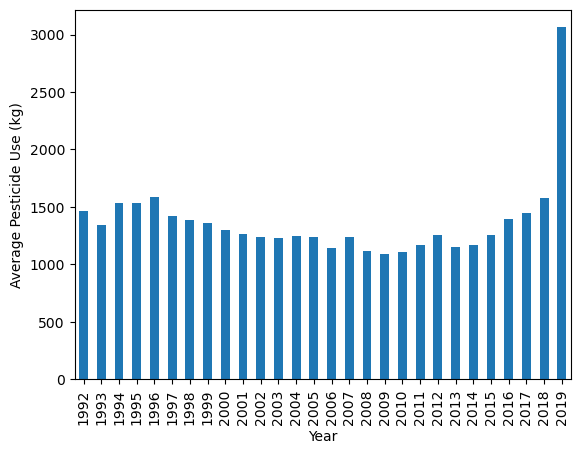

In [14]:
# average pesticide use across all counties and all compounds
df_groups.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Average Pesticide Use (kg)')
plt.show()

<Axes: >

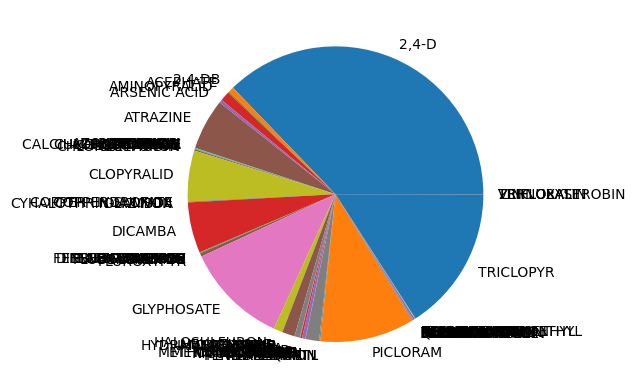

In [15]:
# pick a random county and plot cumulative pesticide use across all available years
counties = df['STATE_COUNTY_CODE'].unique()
this_county = counties[np.random.randint(low=0,high=len(counties)+1)]
df_county = df[df['STATE_COUNTY_CODE']==this_county].groupby('COMPOUND')['EPEST_MEAN_KG'].sum()
df_county.plot.pie()

In [16]:
# plotting a single compound use across years for this county
this_compound = '2,4-D'
df_subset = df[(df['STATE_COUNTY_CODE']==this_county) & (df['COMPOUND']==this_compound)]
sorted_df = df_subset.sort_values(by='YEAR')
sorted_df

,COMPOUND,YEAR,STATE_FIPS_CODE,COUNTY_FIPS_CODE,EPEST_LOW_KG,EPEST_HIGH_KG,STATE_COUNTY_CODE,EPEST_MEAN_KG
2600,"2,4-D",1992,48,261,112.4,6780.4,48261,3446.40
2602,"2,4-D",1993,48,261,105.6,125.6,48261,115.60
2602,"2,4-D",1994,48,261,2134.5,2146.8,48261,2140.65
2600,"2,4-D",1995,48,261,2332.1,2374.6,48261,2353.35
2600,"2,4-D",1996,48,261,0.1,2788.1,48261,1394.10
2598,"2,4-D",1997,48,261,3308.9,3309.2,48261,3309.05
2596,"2,4-D",1998,48,261,8592.5,8592.5,48261,8592.50
2595,"2,4-D",1999,48,261,4496.4,4496.4,48261,4496.40
2589,"2,4-D",2000,48,261,2244.5,2244.5,48261,2244.50
2594,"2,4-D",2001,48,261,357.7,357.7,48261,357.70


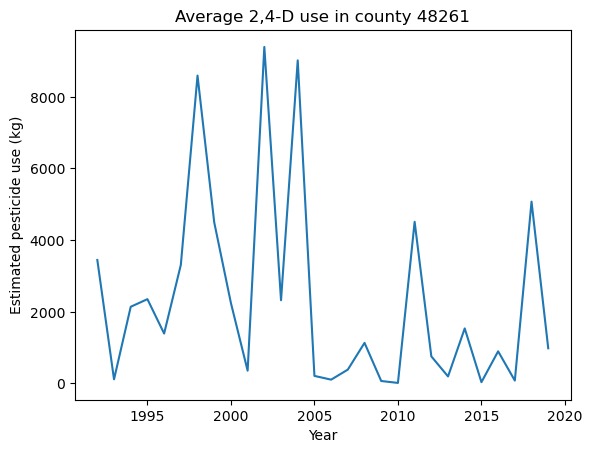

In [17]:
plt.plot(sorted_df['YEAR'],sorted_df['EPEST_MEAN_KG'])
plt.title('Average '+this_compound+' use in county '+str(this_county))
plt.xlabel('Year')
plt.ylabel('Estimated pesticide use (kg)')
plt.show()